# AlphaZero: Self-Play Reinforcement Learning with Monte Carlo Tree Search

**A hands-on tutorial with theory and PyTorch implementation**

---

In March 2016, **AlphaGo** ([Silver et al., 2016](https://www.nature.com/articles/nature16961)) defeated Lee Sedol,
one of the strongest Go players in history — a milestone that many experts had expected to be a decade away.
AlphaGo learned first from human expert games and then from self-play. Eighteen months later, **AlphaGo Zero**
([Silver et al., 2017](https://www.nature.com/articles/nature24270)) discarded the human data entirely: starting from
random play and knowing only the rules, it surpassed every previous version within days. **AlphaZero**
([Silver et al., 2018](https://www.science.org/doi/10.1126/science.aar6404)) then showed that the *same* algorithm,
unchanged, mastered chess and shogi as well, beating the strongest existing engines.

The algorithm is a beautiful synthesis of three ideas from this tutorial series: a **policy/value network**
(as in actor-critic methods), **planning with a known model** (as in dynamic programming — but selective, via
Monte Carlo Tree Search), and **policy iteration**: search produces a better policy than the network alone, and the
network is trained to imitate the search. This notebook implements AlphaZero from scratch on Tic-Tac-Toe — small
enough to train in minutes and to verify against a *perfect* minimax player.

## What you will learn

1. **Monte Carlo Tree Search (MCTS)** with the PUCT selection rule.
2. How a **single network with policy and value heads** guides and is improved by search.
3. The **self-play training loop**: search → play → train → repeat, as a form of policy iteration.
4. A **from-scratch PyTorch implementation** on Tic-Tac-Toe, evaluated against random and perfect opponents.
5. How AlphaZero relates to the rest of RL, and to MuZero and modern LLM reasoning systems.

## Notebook outline

1. Two-player zero-sum games as RL
2. Monte Carlo Tree Search with neural guidance (PUCT)
3. The AlphaZero training loop
4. Implementation: game, network, MCTS, self-play, training
5. Training and evaluation against random and perfect players
6. Looking inside: priors, search, and values
7. **Visual demonstration** of the trained agent playing
8. Strengths, weaknesses & connections
9. References

## 0. Setup

We use PyTorch for function approximation, `gymnasium` (the maintained fork of OpenAI Gym) for environments,
`pygame` for rendering frames, and `imageio` to turn rendered frames into GIFs. If you don't have these installed,
uncomment the install cell.

In [1]:
# !pip install torch gymnasium pygame imageio matplotlib numpy

In [2]:
import math
import random
import time
import warnings
from collections import deque
from dataclasses import dataclass
from typing import List, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import gymnasium as gym
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", message="pkg_resources is deprecated")   # noisy pygame import warning

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}, gymnasium version: {gym.__version__}")

Using device: cpu
PyTorch version: 2.11.0, gymnasium version: 1.2.3


### Visualization helpers

Every tutorial in this folder ends with a *visual demonstration* of the trained agent. The three helpers below are
shared across notebooks:

- `record_episode` rolls out one episode with a given action function and collects rendered RGB frames.
- `show_filmstrip` shows a handful of evenly spaced frames as a static image (renders everywhere, including GitHub).
- `save_gif` writes an animated GIF to `media/` and displays it inline.

In [3]:
import os
import imageio.v3 as iio
from IPython.display import Image, display

MEDIA_DIR = "media"
os.makedirs(MEDIA_DIR, exist_ok=True)


def record_episode(env, act_fn, seed=0, max_steps=1000):
    """Roll out one episode in an env created with render_mode="rgb_array".

    `act_fn(obs) -> action`. Returns (frames, episode_return, episode_length).
    """
    obs, _ = env.reset(seed=seed)
    frames, ep_ret = [env.render()], 0.0
    for _ in range(max_steps):
        obs, reward, terminated, truncated, _ = env.step(act_fn(obs))
        ep_ret += reward
        frames.append(env.render())
        if terminated or truncated:
            break
    return frames, ep_ret, len(frames) - 1


def show_filmstrip(frames, n=8, title=None, captions=None):
    """Static preview: n evenly spaced frames side by side."""
    idx = np.linspace(0, len(frames) - 1, num=min(n, len(frames)), dtype=int)
    h, w = np.asarray(frames[0]).shape[:2]
    fw = 2.3
    fig, axes = plt.subplots(1, len(idx), figsize=(fw * len(idx), fw * h / w + 0.6))
    for ax, i in zip(np.atleast_1d(axes), idx):
        ax.imshow(frames[i])
        ax.axis("off")
        ax.set_title(captions[i] if captions is not None else f"t = {i}", fontsize=9)
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def save_gif(frames, name, fps=30, max_frames=240, downscale=2):
    """Subsample/downscale frames, write media/<name>.gif and return an inline Image."""
    step = max(1, int(np.ceil(len(frames) / max_frames)))
    small = np.stack([np.asarray(f)[::downscale, ::downscale] for f in frames[::step]])
    path = os.path.join(MEDIA_DIR, f"{name}.gif")
    iio.imwrite(path, small, duration=int(1000 * step / fps), loop=0)
    print(f"Saved {path}  ({small.shape[0]} frames, {os.path.getsize(path) / 1e6:.2f} MB)")
    return Image(filename=path)

## 1. Two-Player Zero-Sum Games as RL

A perfect-information two-player game (Go, chess, Tic-Tac-Toe) is an MDP where the "environment" is the opponent.
For **self-play** we adopt a single convention: every position is represented from the perspective of the
**player to move** (the *canonical* form: my stones are $+1$, the opponent's $-1$), and the **value** $v \in [-1, 1]$ of a
position is the expected outcome for the player to move ($+1$ = win, $-1$ = loss, $0$ = draw). After a move the
perspective flips, so the value of the resulting position, from the *next* player's point of view, is $-v$. This
minus sign is the entire "adversarial" part of the algorithm.

There are no intermediate rewards: the only reward is the game result $z \in \{-1, 0, +1\}$ at the end.

## 2. Monte Carlo Tree Search with Neural Guidance

AlphaZero uses one network $f_\theta(s) = (\mathbf{p}, v)$: a **policy head** giving a prior probability $p_a$ for every
move, and a **value head** predicting the outcome. The network alone plays decently; **search** makes it play much better.

Each MCTS **simulation** walks from the root to a leaf and back, maintaining for every edge $(s,a)$ a visit count
$N(s,a)$, a total value $W(s,a)$, a mean value $Q(s,a) = W/N$, and the prior $P(s,a)$:

1. **Select.** From the root, repeatedly choose the action maximizing the **PUCT** score

   $$
   \boxed{\;a^* = \arg\max_a\; Q(s,a) + c_{\text{puct}}\; P(s,a)\, \frac{\sqrt{\sum_b N(s,b)}}{1 + N(s,a)}\;}
   $$

   The first term exploits (high estimated value), the second explores (high prior, few visits); the exploration
   bonus shrinks as an action is visited more. Continue until reaching a leaf (a position not yet expanded) or a terminal position.
2. **Expand & evaluate.** At the leaf, call the network: store the priors $P(s,\cdot) = \mathbf{p}$ for its children and
   take $v$ as the leaf's value. (AlphaGo used random rollouts here; AlphaGo Zero replaced them entirely with the value head.)
   At a terminal position the true game result is used instead.
3. **Backup.** Walk back up the path, adding $1$ to every $N$ and the value to every $W$ — **flipping the sign at every
   level**, since consecutive positions belong to different players.

After $n$ simulations, the root's visit counts define the **search policy**
$\pi(a \mid s_{\text{root}}) \propto N(s_{\text{root}}, a)^{1/\tau}$, with a temperature $\tau$. The move is sampled from $\pi$
($\tau = 1$, for exploration, early in self-play games) or taken greedily ($\tau \to 0$).

To encourage exploration in self-play, **Dirichlet noise** is mixed into the root priors:
$P(s_{\text{root}}, a) \leftarrow (1-\varepsilon) p_a + \varepsilon\, \eta_a$, $\eta \sim \text{Dir}(\alpha)$.

## 3. The AlphaZero Training Loop

The key insight is that **MCTS is a policy improvement operator**: given the network's policy $\mathbf{p}$ and value $v$, the
search policy $\pi$ is stronger than $\mathbf{p}$, and the game outcome $z$ is a better estimate than $v$. Training the network
toward $(\pi, z)$ therefore improves it, which improves the search, and so on — generalized policy iteration where the
"policy improvement" step is a tree search.

**Loop:**

1. **Self-play.** Play games against yourself using MCTS with the current network. For every position record
   $(s, \pi, z)$: the canonical board, the search policy, and the eventual game result *from that position's player's perspective*.
2. **Train.** Sample positions from a replay buffer of recent games and minimize

   $$
   \boxed{\;L(\theta) \;=\; (z - v_\theta(s))^2 \;-\; \pi^\top \log \mathbf{p}_\theta(s) \;+\; c\,\|\theta\|^2\;}
   $$

   — value regression plus cross-entropy between the search policy and the network policy.
3. **Repeat.** (AlphaGo Zero gated new networks by an evaluation match; AlphaZero just keeps training a single network.)

**Data augmentation.** Board games often have symmetries; Tic-Tac-Toe has 8 (rotations and reflections). Each recorded
position yields 8 training examples, which the original AlphaGo Zero also exploited for Go.

That's it. No opening books, no human games, no hand-crafted evaluation. The same code trained on chess, shogi and Go.

## 4. Implementation

### 4.1 The game

Boards are length-9 arrays in canonical form ($+1$ = player to move). `step` places a stone and returns the new board
already flipped to the *next* player's perspective, plus the terminal value for the player who just moved.

In [4]:
LINES = np.array([[0, 1, 2], [3, 4, 5], [6, 7, 8], [0, 3, 6], [1, 4, 7], [2, 5, 8], [0, 4, 8], [2, 4, 6]])


class TicTacToe:
    n_actions = 9

    @staticmethod
    def initial():
        return np.zeros(9, dtype=np.int8)

    @staticmethod
    def legal_actions(board):
        return np.flatnonzero(board == 0)

    @staticmethod
    def step(board, action):
        """Apply `action` for the player to move (+1). Returns (next_board_canonical, terminal, value_for_mover)."""
        nxt = board.copy(); nxt[action] = 1
        if (nxt[LINES].sum(1) == 3).any():
            return -nxt, True, 1.0           # the mover won
        if (nxt == 0).sum() == 0:
            return -nxt, True, 0.0           # draw
        return -nxt, False, 0.0

    @staticmethod
    def key(board):
        return board.tobytes()


# The 8 symmetries of the 3x3 board as index permutations (applied to both the board and the policy vector)
_idx = np.arange(9).reshape(3, 3)
SYMMETRIES = []
for k in range(4):
    r = np.rot90(_idx, k)
    SYMMETRIES.append(r.flatten()); SYMMETRIES.append(np.fliplr(r).flatten())

b = TicTacToe.initial()
for a in [4, 0, 2, 6, 3, 5, 1, 7]:
    b, terminal, value = TicTacToe.step(b, a)
print("final canonical board (perspective of the player to move):\n", b.reshape(3, 3), "\nterminal:", terminal, " value for mover:", value)

final canonical board (perspective of the player to move):
 [[-1  1  1]
 [ 1  1 -1]
 [-1 -1  0]] 
terminal: False  value for mover: 0.0


### 4.2 The network

Tiny by AlphaZero standards (which used a 20–40 block ResNet): three one-hot planes (mine / theirs / empty) flattened,
two hidden layers, then a policy head (9 logits) and a value head ($\tanh$).

In [5]:
class PolicyValueNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.trunk = nn.Sequential(nn.Linear(27, hidden), nn.ReLU(), nn.Linear(hidden, hidden), nn.ReLU())
        self.policy_head = nn.Linear(hidden, 9)
        self.value_head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 1), nn.Tanh())

    @staticmethod
    def encode(boards):
        """(B, 9) int boards -> (B, 27) float planes: mine, theirs, empty."""
        b = torch.as_tensor(np.asarray(boards), dtype=torch.float32, device=device)
        return torch.cat([(b == 1).float(), (b == -1).float(), (b == 0).float()], dim=-1)

    def forward(self, x):
        h = self.trunk(x)
        return self.policy_head(h), self.value_head(h).squeeze(-1)

    @torch.no_grad()
    def predict(self, board):
        """Priors over legal moves and the value, for a single canonical board."""
        logits, v = self(self.encode(board[None]))
        logits = logits[0].cpu().numpy(); mask = board == 0
        logits[~mask] = -1e9
        p = np.exp(logits - logits.max()); p /= p.sum()
        return p, float(v.item())

### 4.3 Monte Carlo Tree Search

`Node` stores the edge statistics of its children. `mcts` runs `n_simulations` and returns the root visit
distribution. Note the sign flip in the backup loop.

In [6]:
class Node:
    __slots__ = ("board", "prior", "N", "W", "children", "terminal", "terminal_value")

    def __init__(self, board, prior, terminal=False, terminal_value=0.0):
        self.board, self.prior = board, prior
        self.N, self.W = 0, 0.0
        self.children = {}                      # action -> Node
        self.terminal, self.terminal_value = terminal, terminal_value   # value from the perspective of the player to move here

    @property
    def Q(self):
        return self.W / self.N if self.N > 0 else 0.0

    def expanded(self):
        return len(self.children) > 0


def expand(node, net):
    """Create children with network priors; return the network value for the player to move at `node`."""
    priors, value = net.predict(node.board)
    for a in TicTacToe.legal_actions(node.board):
        child_board, terminal, mover_value = TicTacToe.step(node.board, a)
        # child's terminal value is from the perspective of the player to move at the child = the opponent of the mover
        node.children[a] = Node(child_board, priors[a], terminal, -mover_value)
    return value


def select_child(node, c_puct):
    sqrt_N = math.sqrt(node.N + 1e-8)
    best, best_score = None, -np.inf
    for a, child in node.children.items():
        # child.Q is stored from the perspective of the player who moves INTO the child (i.e. the player to move at `node`)
        score = child.Q + c_puct * child.prior * sqrt_N / (1 + child.N)
        if score > best_score:
            best, best_score = a, score
    return best


def mcts(root_board, net, n_simulations=50, c_puct=1.5, dirichlet_alpha=1.0, noise_eps=0.25, rng=None):
    """Run MCTS from `root_board`; return (visit-count policy over 9 actions, root node)."""
    root = Node(root_board, 1.0)
    expand(root, net)
    if noise_eps > 0 and rng is not None:                       # root exploration noise (self-play only)
        actions = list(root.children.keys())
        noise = rng.dirichlet([dirichlet_alpha] * len(actions))
        for a, n in zip(actions, noise):
            root.children[a].prior = (1 - noise_eps) * root.children[a].prior + noise_eps * n

    for _ in range(n_simulations):
        node, path = root, [root]
        # 1. select down to a leaf
        while node.expanded() and not node.terminal:
            node = node.children[select_child(node, c_puct)]
            path.append(node)
        # 2. evaluate the leaf (value from the perspective of the player to move at the leaf)
        value = node.terminal_value if node.terminal else expand(node, net)
        # 3. backup: the leaf's W is from the perspective of the player who moved into it, i.e. -value; alternate up the path
        v = -value
        for n in reversed(path):
            n.N += 1; n.W += v; v = -v

    visits = np.zeros(9)
    for a, child in root.children.items():
        visits[a] = child.N
    return visits / visits.sum(), root

### 4.4 Self-play and training

`self_play_game` plays one game with MCTS on both sides, returning training triples $(s, \pi, z)$. Moves are sampled with
$\tau = 1$ for the first `temperature_moves` plies and greedily afterwards. `train_step` runs minibatch SGD on the buffer,
with the 8 symmetries applied on the fly.

In [7]:
@dataclass
class AZConfig:
    n_iterations: int = 40
    games_per_iteration: int = 30
    n_simulations: int = 100
    c_puct: float = 1.5
    dirichlet_alpha: float = 1.0
    noise_eps: float = 0.25
    temperature_moves: int = 4       # sample moves from pi for the first k plies, then play greedily
    buffer_iterations: int = 6       # keep positions from the last k iterations
    batch_size: int = 128
    train_steps_per_iteration: int = 80
    lr: float = 2e-3
    weight_decay: float = 1e-4
    eval_every: int = 5
    eval_games: int = 20
    eval_simulations: int = 100


def self_play_game(net, cfg, rng):
    board, history = TicTacToe.initial(), []
    ply = 0
    while True:
        pi, _ = mcts(board, net, cfg.n_simulations, cfg.c_puct, cfg.dirichlet_alpha, cfg.noise_eps, rng)
        history.append((board.copy(), pi))
        action = rng.choice(9, p=pi) if ply < cfg.temperature_moves else int(pi.argmax())
        board, terminal, mover_value = TicTacToe.step(board, action)
        ply += 1
        if terminal:
            break
    # z for each recorded position, from that position's mover's perspective: the last mover got `mover_value`
    examples, z = [], mover_value
    for s, pi in reversed(history):
        examples.append((s, pi, z)); z = -z
    return examples, len(history)


def augment(examples):
    out = []
    for s, pi, z in examples:
        for perm in SYMMETRIES:
            out.append((s[perm], pi[perm], z))
    return out


def train_step(net, optimizer, buffer, cfg, rng):
    idx = rng.integers(0, len(buffer), cfg.batch_size)
    boards = np.stack([buffer[i][0] for i in idx]); pis = np.stack([buffer[i][1] for i in idx]); zs = np.array([buffer[i][2] for i in idx], dtype=np.float32)
    logits, v = net(PolicyValueNet.encode(boards))
    pis_t, zs_t = torch.as_tensor(pis, dtype=torch.float32, device=device), torch.as_tensor(zs, device=device)
    policy_loss = -(pis_t * F.log_softmax(logits, dim=-1)).sum(-1).mean()
    value_loss = F.mse_loss(v, zs_t)
    loss = policy_loss + value_loss
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    return policy_loss.item(), value_loss.item()

### 4.5 Opponents for evaluation

Tic-Tac-Toe is small enough to solve exactly, so we can measure progress against a **perfect minimax player** (which
picks uniformly among the optimal moves, to avoid always playing the same game) and against a **random player**. A
perfect player never loses; against another perfect player every game is a draw.

In [8]:
from functools import lru_cache

@lru_cache(maxsize=None)
def minimax(board_bytes):
    """Exact value (for the player to move) and the list of optimal moves, for a canonical board."""
    board = np.frombuffer(board_bytes, dtype=np.int8)
    best_val, best_moves = -2.0, []
    for a in TicTacToe.legal_actions(board):
        nxt, terminal, mover_value = TicTacToe.step(board, a)
        val = mover_value if terminal else -minimax(nxt.tobytes())[0]
        if val > best_val + 1e-9:
            best_val, best_moves = val, [int(a)]
        elif abs(val - best_val) < 1e-9:
            best_moves.append(int(a))
    return best_val, tuple(best_moves)


def minimax_player(board, rng):
    return int(rng.choice(minimax(board.tobytes())[1]))

def random_player(board, rng):
    return int(rng.choice(TicTacToe.legal_actions(board)))

def make_az_player(net, n_simulations):
    def play(board, rng):
        pi, _ = mcts(board, net, n_simulations, noise_eps=0.0)
        return int(pi.argmax())
    return play


def play_game(player_first, player_second, rng):
    """Returns +1 if the first player wins, -1 if the second wins, 0 for a draw, and the list of (absolute board, mover) states."""
    board, to_move, states = TicTacToe.initial(), +1, []
    players = {+1: player_first, -1: player_second}
    while True:
        action = players[to_move](board, rng)
        board, terminal, mover_value = TicTacToe.step(board, action)
        states.append((-board * to_move, to_move, action))   # absolute board: +1 = first player's stones
        if terminal:
            return mover_value * to_move, states
        to_move = -to_move


def evaluate_vs(net, opponent, cfg, rng, n_games=20):
    """Play n games as first player and n as second. Returns dict of win/draw/loss rates."""
    az = make_az_player(net, cfg.eval_simulations)
    results = []
    for g in range(n_games):
        results.append(play_game(az, opponent, rng)[0])          # AlphaZero moves first
        results.append(-play_game(opponent, az, rng)[0])         # AlphaZero moves second
    results = np.array(results)
    return dict(win=float((results == 1).mean()), draw=float((results == 0).mean()), loss=float((results == -1).mean()))

## 5. Training and Evaluation

Every few iterations we pause to play against both opponents. Perfect play means **0% losses vs. minimax**; against
the random player the agent should win almost every game.

In [9]:
def train_alphazero(cfg: AZConfig, seed=SEED, verbose=True):
    torch.manual_seed(seed); rng = np.random.default_rng(seed)
    net = PolicyValueNet().to(device)
    optimizer = torch.optim.Adam(net.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    buffer_by_iter, logs = [], dict(iteration=[], policy_loss=[], value_loss=[], game_length=[], eval_iteration=[], vs_minimax=[], vs_random=[])

    for it in range(1, cfg.n_iterations + 1):
        # ---- self-play ----
        net.eval(); examples, lengths = [], []
        for _ in range(cfg.games_per_iteration):
            ex, L = self_play_game(net, cfg, rng); examples += ex; lengths.append(L)
        buffer_by_iter.append(augment(examples)); buffer_by_iter = buffer_by_iter[-cfg.buffer_iterations:]
        buffer = [e for chunk in buffer_by_iter for e in chunk]
        # ---- training ----
        net.train(); pl, vl = [], []
        for _ in range(cfg.train_steps_per_iteration):
            p, v = train_step(net, optimizer, buffer, cfg, rng); pl.append(p); vl.append(v)
        net.eval()
        logs["iteration"].append(it); logs["policy_loss"].append(np.mean(pl)); logs["value_loss"].append(np.mean(vl)); logs["game_length"].append(np.mean(lengths))
        msg = f"iter {it:2d} | buffer {len(buffer):5d} | policy loss {np.mean(pl):.3f} | value loss {np.mean(vl):.3f} | mean game length {np.mean(lengths):.1f}"
        # ---- evaluation ----
        if it % cfg.eval_every == 0 or it == 1:
            vm = evaluate_vs(net, minimax_player, cfg, rng, cfg.eval_games); vr = evaluate_vs(net, random_player, cfg, rng, cfg.eval_games)
            logs["eval_iteration"].append(it); logs["vs_minimax"].append(vm); logs["vs_random"].append(vr)
            msg += f" | vs minimax W/D/L {vm['win']:.2f}/{vm['draw']:.2f}/{vm['loss']:.2f} | vs random W/D/L {vr['win']:.2f}/{vr['draw']:.2f}/{vr['loss']:.2f}"
        if verbose:
            print(msg)
    return net, logs


cfg = AZConfig()
t0 = time.time()
net, logs = train_alphazero(cfg)
print(f"\nTrained in {time.time() - t0:.0f}s")

iter  1 | buffer  1824 | policy loss 1.885 | value loss 0.377 | mean game length 7.6 | vs minimax W/D/L 0.00/0.85/0.15 | vs random W/D/L 0.93/0.05/0.03


iter  2 | buffer  3608 | policy loss 1.526 | value loss 0.274 | mean game length 7.4


iter  3 | buffer  5312 | policy loss 1.419 | value loss 0.240 | mean game length 7.1


iter  4 | buffer  7296 | policy loss 1.333 | value loss 0.202 | mean game length 8.3


iter  5 | buffer  9344 | policy loss 1.232 | value loss 0.166 | mean game length 8.5 | vs minimax W/D/L 0.00/1.00/0.00 | vs random W/D/L 0.97/0.03/0.00


...

iter 36 | buffer 12496 | policy loss 0.897 | value loss 0.050 | mean game length 8.5


iter 37 | buffer 12520 | policy loss 0.883 | value loss 0.055 | mean game length 8.8


iter 38 | buffer 12408 | policy loss 0.895 | value loss 0.055 | mean game length 8.2


iter 39 | buffer 12424 | policy loss 0.885 | value loss 0.059 | mean game length 8.7


iter 40 | buffer 12368 | policy loss 0.894 | value loss 0.057 | mean game length 8.7 | vs minimax W/D/L 0.00/1.00/0.00 | vs random W/D/L 0.93/0.07/0.00

Trained in 32s


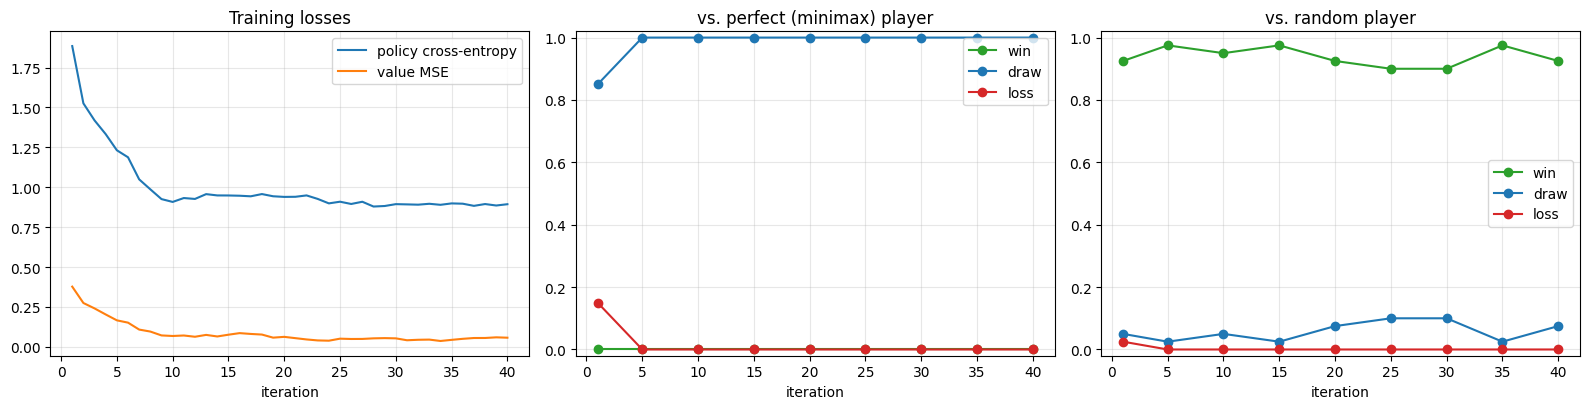

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
axes[0].plot(logs["iteration"], logs["policy_loss"], label="policy cross-entropy"); axes[0].plot(logs["iteration"], logs["value_loss"], label="value MSE")
axes[0].set_xlabel("iteration"); axes[0].set_title("Training losses"); axes[0].legend(); axes[0].grid(alpha=0.3)
ev = logs["eval_iteration"]
for key, ax, title in [("vs_minimax", axes[1], "vs. perfect (minimax) player"), ("vs_random", axes[2], "vs. random player")]:
    for outcome, color in [("win", "C2"), ("draw", "C0"), ("loss", "C3")]:
        ax.plot(ev, [r[outcome] for r in logs[key]], "o-", color=color, label=outcome)
    ax.set_ylim(-0.02, 1.02); ax.set_xlabel("iteration"); ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Reading the plots.** Against the perfect player, the loss rate should drop to zero and every game becomes a draw —
the signature of perfect play (Tic-Tac-Toe is a draw with best play from both sides). Against the random player the
win rate climbs toward 100%; the few draws that remain are games where the random player happened to block. The
value loss falls as the network learns to recognize won/lost/drawn positions without search.

### 5.1 Final strength: with and without search

How much of the strength is the network, and how much the search? We evaluate the *raw* network (argmax of the policy
head, no MCTS) against the same opponents.

In [11]:
def raw_net_player(board, rng):
    p, _ = net.predict(board); return int(p.argmax())

rng_eval = np.random.default_rng(123)
az = make_az_player(net, 100)
def score(player, opp, n=30):
    res = np.array([play_game(player, opp, rng_eval)[0] for _ in range(n)] + [-play_game(opp, player, rng_eval)[0] for _ in range(n)])
    return f"W {np.mean(res == 1):.2f} / D {np.mean(res == 0):.2f} / L {np.mean(res == -1):.2f}"

print(f"{'':28s} {'vs minimax':>26s} {'vs random':>26s}")
print(f"{'raw network (no search)':28s} {score(raw_net_player, minimax_player):>26s} {score(raw_net_player, random_player):>26s}")
print(f"{'network + MCTS (100 sims)':28s} {score(az, minimax_player):>26s} {score(az, random_player):>26s}")

                                             vs minimax                  vs random
raw network (no search)        W 0.00 / D 1.00 / L 0.00   W 0.80 / D 0.20 / L 0.00


network + MCTS (100 sims)      W 0.00 / D 1.00 / L 0.00   W 0.85 / D 0.15 / L 0.00


## 6. Looking Inside: Priors, Search, and Values

For a few positions we compare the network's prior $\mathbf{p}$ with the MCTS visit distribution $\pi$, and print the
network's value next to the exact minimax value and the set of optimal moves. Squares are numbered 0–8 row by row;
the board is shown from the perspective of the player to move (X).

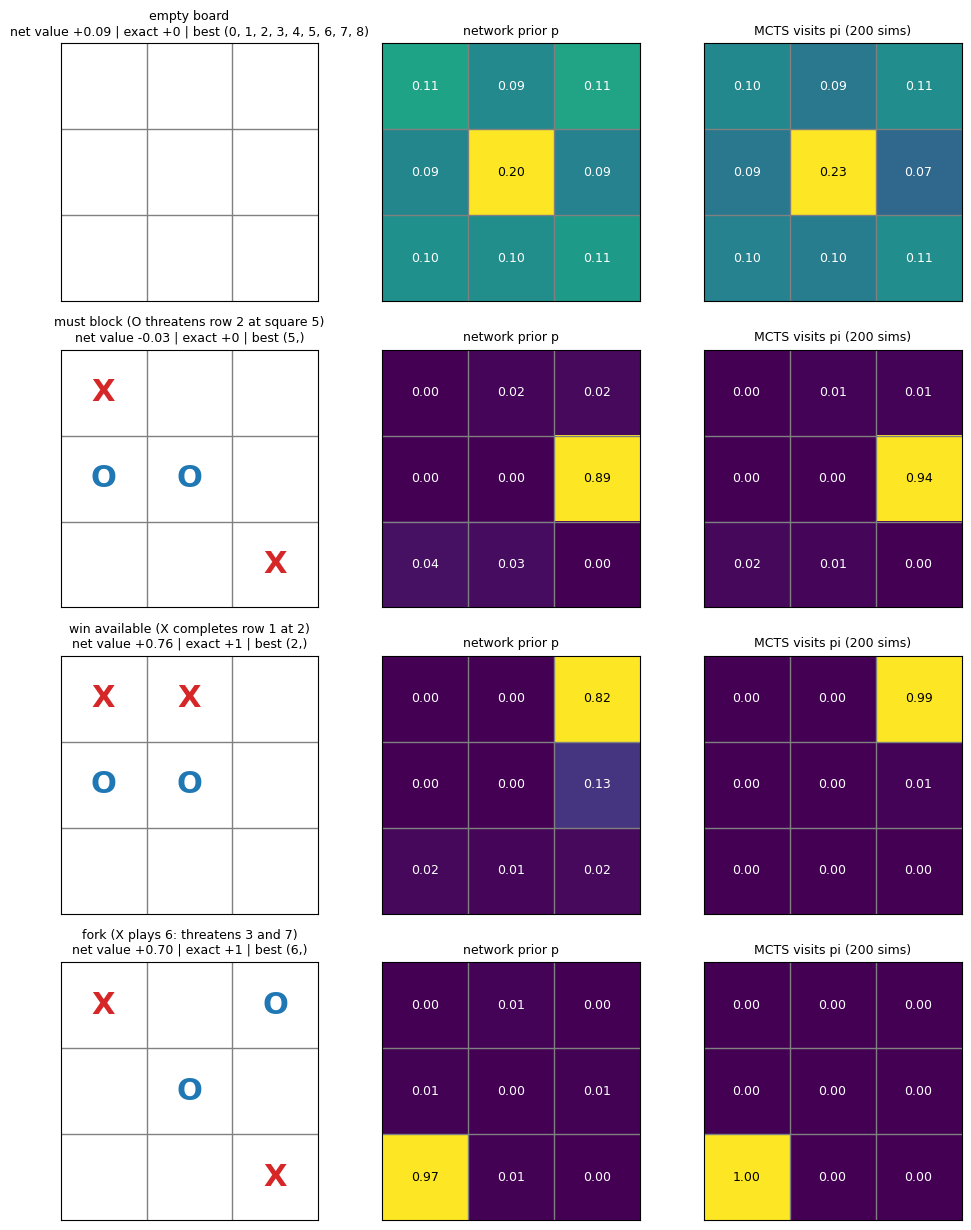

In [12]:
def board_from_string(s):
    """'X.O/.X./...' -> canonical board with X to move (X = +1)."""
    return np.array([{"X": 1, "O": -1, ".": 0}[c] for c in s.replace("/", "")], dtype=np.int8)

positions = {
    "empty board": board_from_string(".../.../..."),
    "must block (O threatens row 2 at square 5)": board_from_string("X../OO./..X"),
    "win available (X completes row 1 at 2)": board_from_string("XX./OO./..."),
    "fork (X plays 6: threatens 3 and 7)": board_from_string("X.O/.O./..X"),
}

fig, axes = plt.subplots(len(positions), 3, figsize=(10, 3.1 * len(positions)))
for row, (name, board) in enumerate(positions.items()):
    prior, v_net = net.predict(board)
    pi, root = mcts(board, net, 200, noise_eps=0.0)
    q_root = -np.mean([c.Q for c in root.children.values()])   # rough: mean over children
    exact, best_moves = minimax(board.tobytes())
    for col, (title, data) in enumerate([("board", board), ("network prior p", prior), ("MCTS visits pi (200 sims)", pi)]):
        ax = axes[row, col]
        if col == 0:
            ax.imshow(np.zeros((3, 3)), cmap="Greys", vmin=0, vmax=1)
            for i in range(9):
                if board[i] != 0:
                    ax.text(i % 3, i // 3, "X" if board[i] == 1 else "O", ha="center", va="center", fontsize=22, weight="bold", color="C3" if board[i] == 1 else "C0")
            ax.set_title(f"{name}\nnet value {v_net:+.2f} | exact {exact:+.0f} | best {best_moves}", fontsize=9)
        else:
            im = ax.imshow(data.reshape(3, 3), cmap="viridis", vmin=0, vmax=max(1e-6, data.max()))
            for i in range(9):
                ax.text(i % 3, i // 3, f"{data[i]:.2f}", ha="center", va="center", color="white" if data[i] < 0.6 * data.max() else "black", fontsize=9)
            ax.set_title(title, fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        for k in range(1, 3):
            ax.axhline(k - 0.5, color="gray", lw=1); ax.axvline(k - 0.5, color="gray", lw=1)
plt.tight_layout(); plt.show()

In tactical positions the search *sharpens* the prior: the network may already favor the right square, but MCTS
concentrates nearly all visits on it. Where the network is unsure, the search corrects it — that gap is exactly the
training signal that drives AlphaZero's improvement.

## 7. Visual Demonstration

Two games, rendered move by move: AlphaZero (X) against the perfect minimax player (O) — a draw is the best possible
result — and AlphaZero (O) against a random player (X), moving second (a random player occasionally blunders into a
draw, so we show the first game AlphaZero wins).

Game 1: draw
Game 2: AlphaZero (O) wins


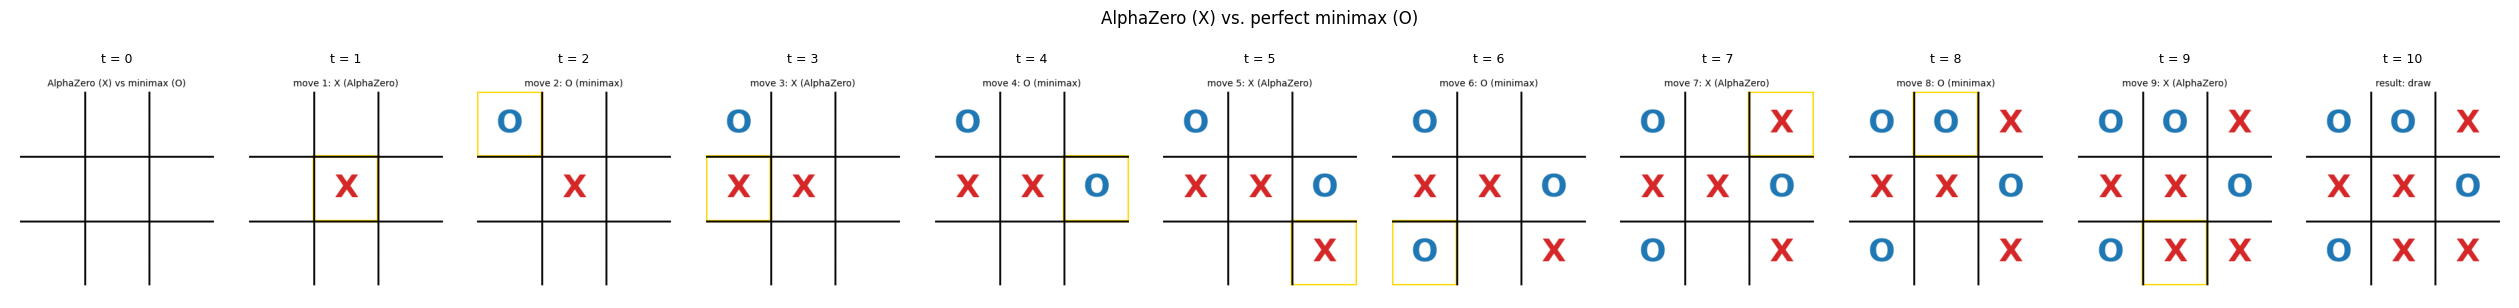

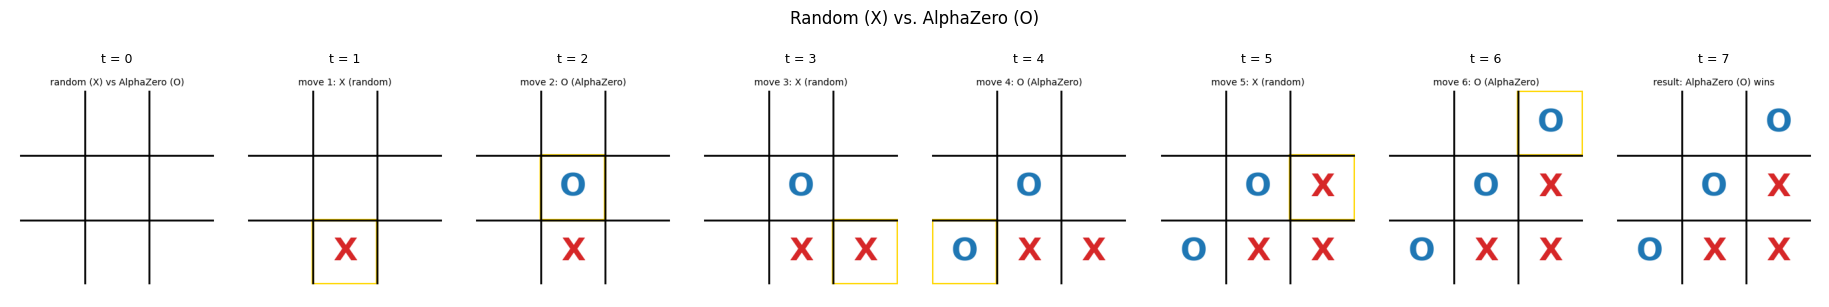

In [13]:
def render_board(abs_board, last_action=None, title=""):
    """abs_board: +1 = X (first player), -1 = O (second player). Returns an RGB frame."""
    fig, ax = plt.subplots(figsize=(3.2, 3.4))
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(2.5, -0.5); ax.set_aspect("equal"); ax.axis("off")
    for k in range(1, 3):
        ax.axhline(k - 0.5, color="black", lw=2); ax.axvline(k - 0.5, color="black", lw=2)
    for i in range(9):
        if abs_board[i] != 0:
            ax.text(i % 3, i // 3, "X" if abs_board[i] == 1 else "O", ha="center", va="center", fontsize=34, weight="bold",
                    color="C3" if abs_board[i] == 1 else "C0")
    if last_action is not None:
        ax.add_patch(plt.Rectangle((last_action % 3 - 0.5, last_action // 3 - 0.5), 1, 1, fill=False, ec="gold", lw=3))
    ax.set_title(title, fontsize=10)
    fig.tight_layout()
    fig.canvas.draw(); frame = np.asarray(fig.canvas.buffer_rgba())[..., :3].copy(); plt.close(fig)
    return frame


def game_frames(first, second, first_name, second_name, rng):
    result, states = play_game(first, second, rng)
    frames = [render_board(np.zeros(9, dtype=np.int8), None, f"{first_name} (X) vs {second_name} (O)")]
    for ply, (abs_board, mover, action) in enumerate(states, 1):
        frames.append(render_board(abs_board, action, f"move {ply}: {'X' if mover == 1 else 'O'} ({first_name if mover == 1 else second_name})"))
    outcome = {1: f"{first_name} (X) wins", -1: f"{second_name} (O) wins", 0: "draw"}[result]
    frames.append(render_board(states[-1][0], None, f"result: {outcome}"))
    return frames, outcome


rng_demo = np.random.default_rng(2024)
az = make_az_player(net, 100)
frames_1, outcome_1 = game_frames(az, minimax_player, "AlphaZero", "minimax", rng_demo)
for _ in range(10):   # a random opponent occasionally stumbles into a draw; show the first game AlphaZero wins
    frames_2, outcome_2 = game_frames(random_player, az, "random", "AlphaZero", rng_demo)
    if outcome_2.startswith("AlphaZero"):
        break
print("Game 1:", outcome_1); print("Game 2:", outcome_2)
show_filmstrip(frames_1, n=len(frames_1), title="AlphaZero (X) vs. perfect minimax (O)")
show_filmstrip(frames_2, n=len(frames_2), title="Random (X) vs. AlphaZero (O)")

Saved media/alphazero_tictactoe.gif  (11 frames, 0.08 MB)


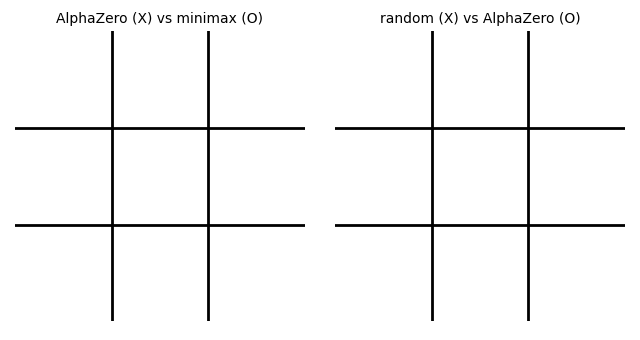

In [14]:
pad = lambda fr, T: fr + [fr[-1]] * (T - len(fr))
T = max(len(frames_1), len(frames_2))
stacked = [np.concatenate([a, b], axis=1) for a, b in zip(pad(frames_1, T), pad(frames_2, T))]
save_gif(stacked, "alphazero_tictactoe", fps=1, downscale=1)

## 8. Strengths, Weaknesses & Connections

### Strengths

- **Tabula rasa.** No human data, no domain heuristics beyond the rules; the same algorithm mastered Go, chess and shogi.
- **Search + learning compound.** The network amortizes search (it plays well instantly); search improves the
  network's targets; together they exceed either alone — a template now called "expert iteration".
- **Superhuman and interpretable-ish**: the visit counts and values are inspectable, unlike a bare policy network.

### Weaknesses

- **Requires a perfect simulator** of the environment (the rules), used many times per move. MuZero removes this by
  learning the model.
- **Enormous compute** at scale: AlphaGo Zero used 4.9 million self-play games on thousands of TPUs; AlphaZero ~700k
  training steps with 5,000 first-generation TPUs generating games.
- **Perfect-information, deterministic, two-player games** only, in the original form. Stochastic or imperfect-information
  games (poker, StarCraft) need different machinery (CFR, population-based training, MuZero variants).
- **Sensitive hyperparameters**: $c_{\text{puct}}$, Dirichlet noise, temperature schedule, and the ratio of self-play to training.

### Connections

- **Dynamic programming**: MCTS is *selective* backward induction — full-width DP is impossible in Go's $10^{170}$ states,
  so search focuses on the promising subtree, guided by the network.
- **Policy iteration / actor-critic**: the policy head is the actor, the value head is the critic, MCTS is the improvement operator.
- **REINFORCE / A3C**: AlphaGo's original policy network was trained with REINFORCE from self-play before the Zero versions.
- **MuZero** (Schrittwieser et al., 2020): same search and training loop but in a *learned* latent model — also masters Atari.
- **EfficientZero**, **Gumbel MuZero**, **Stochastic MuZero**: improved sample efficiency, principled action selection, stochastic environments.
- **LLM reasoning**: "search + learned value" ideas — tree search over reasoning steps, self-play/self-improvement loops,
  process reward models — draw directly on the AlphaZero recipe.

## 9. References

1. **Silver, D., et al.** (2016). *Mastering the game of Go with deep neural networks and tree search.* Nature, 529, 484–489. (AlphaGo)
2. **Silver, D., et al.** (2017). *Mastering the game of Go without human knowledge.* Nature, 550, 354–359. (AlphaGo Zero)
3. **Silver, D., et al.** (2018). *A general reinforcement learning algorithm that masters chess, shogi, and Go through self-play.* Science, 362, 1140–1144. (AlphaZero) [[arXiv]](https://arxiv.org/abs/1712.01815)
4. **Schrittwieser, J., et al.** (2020). *Mastering Atari, Go, chess and shogi by planning with a learned model.* Nature, 588, 604–609. (MuZero)
5. **Coulom, R.** (2006). *Efficient selectivity and backup operators in Monte-Carlo tree search.* Computers and Games.
6. **Kocsis, L., & Szepesvári, C.** (2006). *Bandit based Monte-Carlo planning.* ECML. (UCT)
7. **Rosin, C. D.** (2011). *Multi-armed bandits with episode context.* Annals of Mathematics and AI. (PUCT)
8. **Anthony, T., Tian, Z., & Barber, D.** (2017). *Thinking fast and slow with deep learning and tree search.* NeurIPS. (Expert Iteration)
9. **Danihelka, I., Guez, A., Schrittwieser, J., & Silver, D.** (2022). *Policy improvement by planning with Gumbel.* ICLR.